# Chapter 18: Power Production and Energy Sources

This notebook models gas turbine power generation for an offshore platform,
calculates fuel gas consumption, performs power balance analysis, and estimates
CO₂ emissions. We also investigate the effect of ambient temperature on
available gas turbine power output.

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch30_power_production.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Physical verification uses the same model state, source and interpreter.
sys.path.insert(0, str(BOOK_ROOT / "verification" / "scientific_revision"))
from notebook_physics_checks import PhysicsChecks
_physics = PhysicsChecks(NOTEBOOK_PATH)


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 18.1 Gas Turbine Model

We model a simple-cycle gas turbine using NeqSim's compressor and heater
equipment to represent the thermodynamic cycle:
- **Air compressor** (atmospheric → combustion pressure)
- **Combustor** (heat addition at constant pressure)
- **Power turbine** (expansion to atmospheric pressure)

The net power output is: $W_{net} = W_{turbine} - W_{compressor}$

Fuel gas consumption is calculated from the heat input and fuel LHV.

In [2]:
# jneqsim is bound to the source JVM in the setup cell.

# Fuel gas composition (typical offshore)
fuel_gas = jneqsim.thermo.system.SystemSrkEos(273.15 + 25.0, 30.0)
fuel_gas.addComponent("methane", 0.90)
fuel_gas.addComponent("ethane", 0.05)
fuel_gas.addComponent("propane", 0.03)
fuel_gas.addComponent("CO2", 0.01)
fuel_gas.addComponent("nitrogen", 0.01)
fuel_gas.setMixingRule("classic")

ops = jneqsim.thermodynamicoperations.ThermodynamicOperations(fuel_gas)
ops.TPflash()
fuel_gas.initProperties()
assert _physics.state(fuel_gas, 'calculation_cell_3:fuel_gas', candidate=False)

# Fuel gas properties
fuel_mw = fuel_gas.getMolarMass() * 1000  # g/mol
print(f"Fuel gas MW: {fuel_mw:.1f} g/mol")

# LHV approximation for natural gas: ~50 MJ/kg
LHV_MJ_per_kg = 50.0

# Gas turbine parameters
GT_RATED_POWER_MW = 25.0  # MW rated output
GT_EFFICIENCY = 0.35  # thermal efficiency at ISO conditions
N_TURBINES = 2  # number of gas turbines

print(f"\nGas Turbine Configuration:")
print(f"  Rated power per GT: {GT_RATED_POWER_MW} MW")
print(f"  Number of GTs: {N_TURBINES}")
print(f"  Total available: {GT_RATED_POWER_MW * N_TURBINES} MW")
print(f"  Thermal efficiency: {GT_EFFICIENCY:.0%}")


Fuel gas MW: 18.0 g/mol

Gas Turbine Configuration:
  Rated power per GT: 25.0 MW
  Number of GTs: 2
  Total available: 50.0 MW
  Thermal efficiency: 35%


## 18.2 Fuel Gas Consumption vs Power Load

We calculate the fuel gas flow rate required for different power outputs.
At part load, gas turbine efficiency decreases, increasing specific fuel
consumption.

Figure saved: ../figures/ch30_fuel_consumption.png


ch30_power_production.ipynb:cell5:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


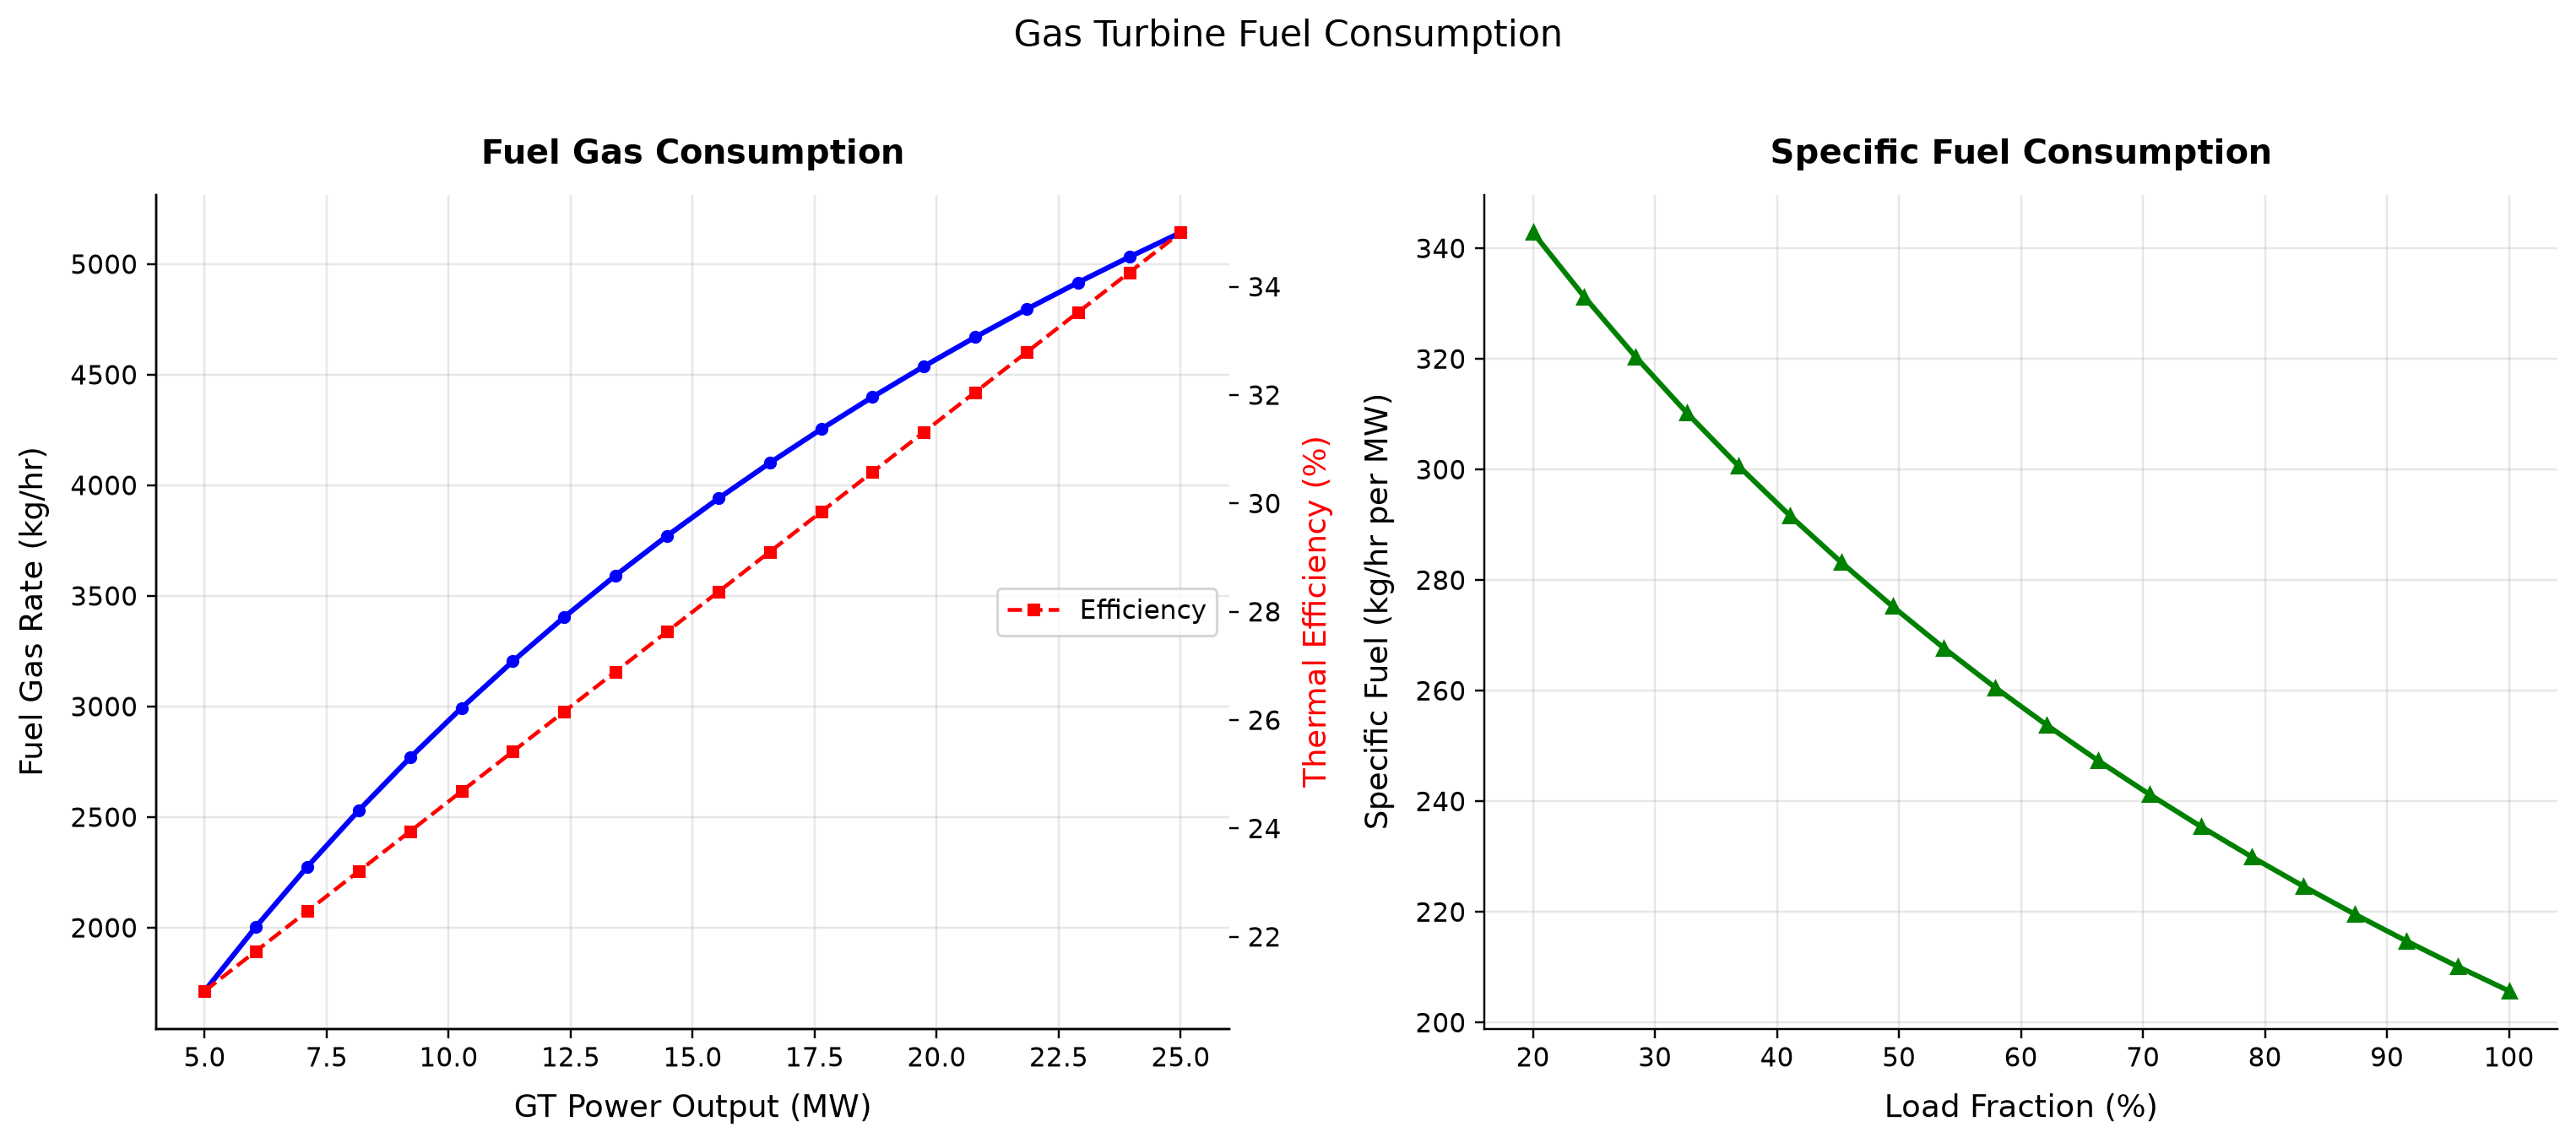

In [3]:
# Power loads from 20% to 100% of rated
load_fractions = np.linspace(0.2, 1.0, 20)
power_loads_MW = load_fractions * GT_RATED_POWER_MW

# Part-load efficiency model: eta = eta_rated * (0.5 + 0.5 * load_fraction)
# This is a simplified representation of GT part-load performance
efficiencies = GT_EFFICIENCY * (0.5 + 0.5 * load_fractions)

# Fuel consumption: Q_fuel = P_output / eta, then mass = Q / LHV
heat_input_MW = power_loads_MW / efficiencies
fuel_rate_kg_hr = heat_input_MW * 1000 / (LHV_MJ_per_kg / 3.6)  # MW to kg/hr
specific_fuel = fuel_rate_kg_hr / power_loads_MW  # kg/hr per MW

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(power_loads_MW, fuel_rate_kg_hr, 'b-o', markersize=4, linewidth=2)
ax1.set_xlabel('GT Power Output (MW)', fontsize=12)
ax1.set_ylabel('Fuel Gas Rate (kg/hr)', fontsize=12)
ax1.set_title('Fuel Gas Consumption', fontsize=13)
ax1.grid(True, alpha=0.3)

ax1_twin = ax1.twinx()
ax1_twin.plot(power_loads_MW, efficiencies * 100, 'r--s', markersize=4, linewidth=1.5, label='Efficiency')
ax1_twin.set_ylabel('Thermal Efficiency (%)', fontsize=12, color='red')
ax1_twin.legend(loc='center right', fontsize=10)

ax2.plot(load_fractions * 100, specific_fuel, 'g-^', markersize=5, linewidth=2)
ax2.set_xlabel('Load Fraction (%)', fontsize=12)
ax2.set_ylabel('Specific Fuel (kg/hr per MW)', fontsize=12)
ax2.set_title('Specific Fuel Consumption', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.suptitle('Gas Turbine Fuel Consumption', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch30_fuel_consumption.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ../figures/ch30_fuel_consumption.png")


**Executed-figure discussion.** Fuel Gas Rate spans 1714–5143 kg/hr across the plotted cases. Specific Fuel spans 205.7–342.9 kg/hr per MW across the plotted cases.

Fuel demand follows delivered shaft or electrical load, fuel heating value and the prime mover’s heat-rate or efficiency model. Part-load efficiency and auxiliary loads can make fuel per unit product increase as production falls. Use a validated heat-rate curve and consistent lower- or higher-heating-value basis, and separate generator output from useful process load.


## 18.3 Power Balance: Demand vs Capacity

We define the power consumers on the platform and create a power balance
pie chart showing the breakdown of power demand.

Platform Power Balance:
  Export Compressor           12.0 MW  (36.4%)
  Gas Injection Comp           8.0 MW  (24.2%)
  Water Injection Pump         5.0 MW  (15.2%)
  Gas Lift Comp                3.0 MW  ( 9.1%)
  Utilities & HVAC             2.5 MW  ( 7.6%)
  Lighting & Safety            1.0 MW  ( 3.0%)
  Oil Export Pump              1.5 MW  ( 4.5%)
---------------------------------------------
  TOTAL DEMAND                33.0 MW
  TOTAL AVAILABLE             50.0 MW
  RESERVE MARGIN              34.0 %
Figure saved: ../figures/ch30_power_demand_pie.png


ch30_power_production.ipynb:cell7:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


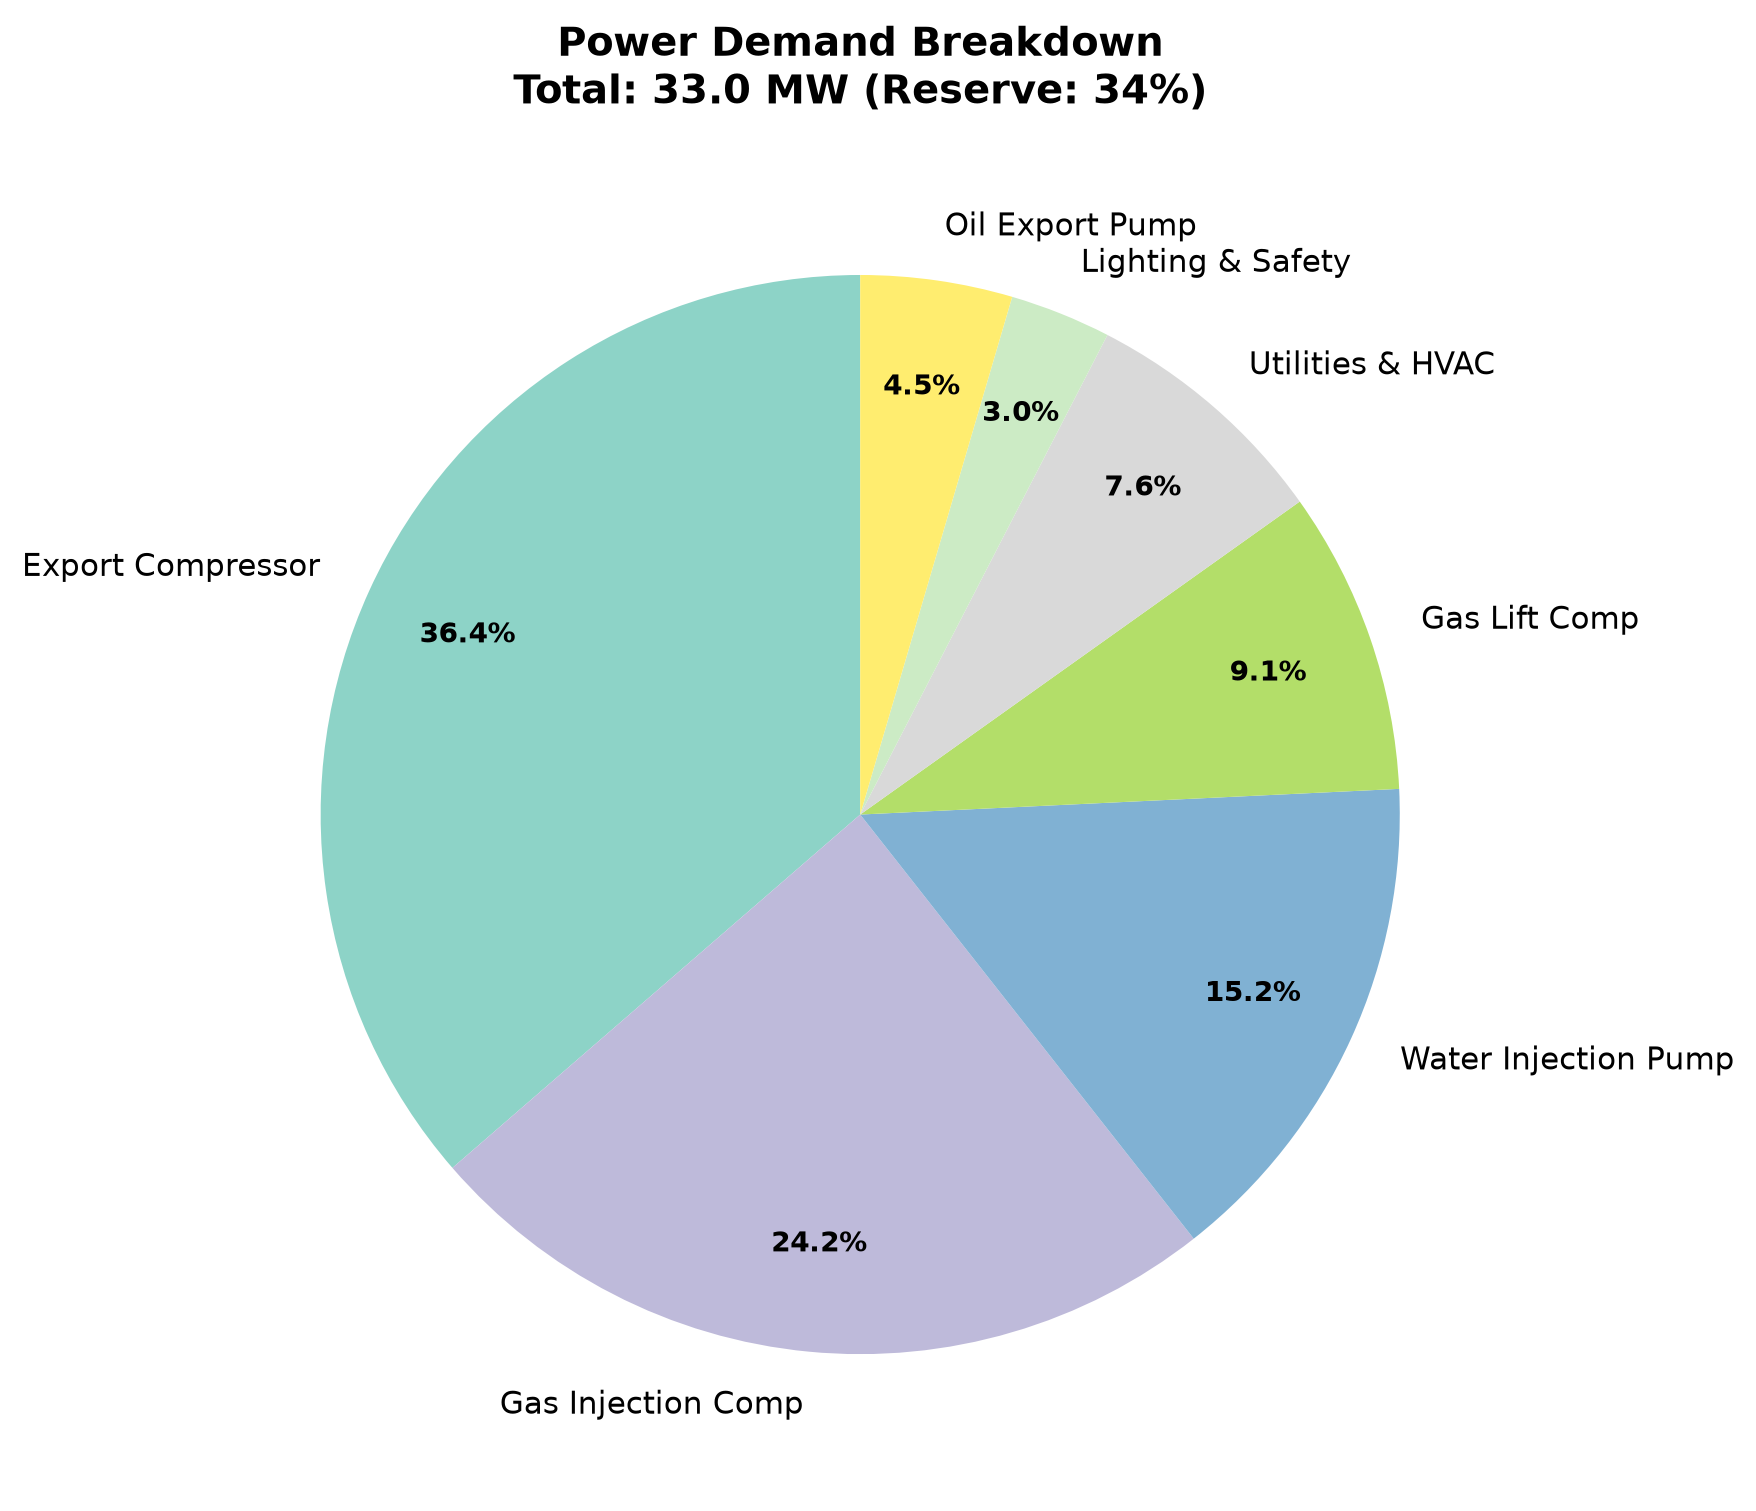

In [4]:
# Platform power consumers
power_consumers = {
    'Export Compressor': 12.0,      # MW
    'Gas Injection Comp': 8.0,      # MW
    'Water Injection Pump': 5.0,    # MW
    'Gas Lift Comp': 3.0,           # MW
    'Utilities & HVAC': 2.5,        # MW
    'Lighting & Safety': 1.0,       # MW
    'Oil Export Pump': 1.5,         # MW
}

total_demand = sum(power_consumers.values())
total_available = GT_RATED_POWER_MW * N_TURBINES
reserve_margin = (total_available - total_demand) / total_available * 100

print("Platform Power Balance:")
print("=" * 45)
for consumer, demand in power_consumers.items():
    pct = demand / total_demand * 100
    print(f"  {consumer:<25s} {demand:6.1f} MW  ({pct:4.1f}%)")
print("-" * 45)
print(f"  {'TOTAL DEMAND':<25s} {total_demand:6.1f} MW")
print(f"  {'TOTAL AVAILABLE':<25s} {total_available:6.1f} MW")
print(f"  {'RESERVE MARGIN':<25s} {reserve_margin:6.1f} %")

# Pie chart
fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.Set3(np.linspace(0, 1, len(power_consumers)))
wedges, texts, autotexts = ax.pie(
    power_consumers.values(),
    labels=power_consumers.keys(),
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.8,
    textprops={'fontsize': 10}
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')

ax.set_title(f'Power Demand Breakdown\nTotal: {total_demand:.1f} MW (Reserve: {reserve_margin:.0f}%)',
             fontsize=13)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch30_power_demand_pie.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ../figures/ch30_power_demand_pie.png")


**Executed-figure discussion.** The assigned loads total 33.0 MW against 50.0 MW of assumed available generation; the allocation is an illustrative platform power budget.

The power shares allocate the stated total among process consumers and auxiliaries; they represent the selected operating case. A demand breakdown identifies the largest consumers but does not prove that the generating system can serve them simultaneously. Reconcile every share with an equipment duty or stated assumption, then check generation, bus allocation and reserve requirements separately.


## 18.4 Ambient Temperature Effect on GT Power

Gas turbine output degrades at higher ambient temperatures because the air
is less dense, reducing mass flow through the compressor. A typical derating
curve follows:

$$P_{available} = P_{rated} \times \left(1 - k_{derate} \times (T_{amb} - T_{ISO})\right)$$

where $T_{ISO} = 15°C$ and $k_{derate} \approx 0.7\%$ per °C.

Figure saved: ../figures/ch30_gt_ambient_temp.png


ch30_power_production.ipynb:cell9:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


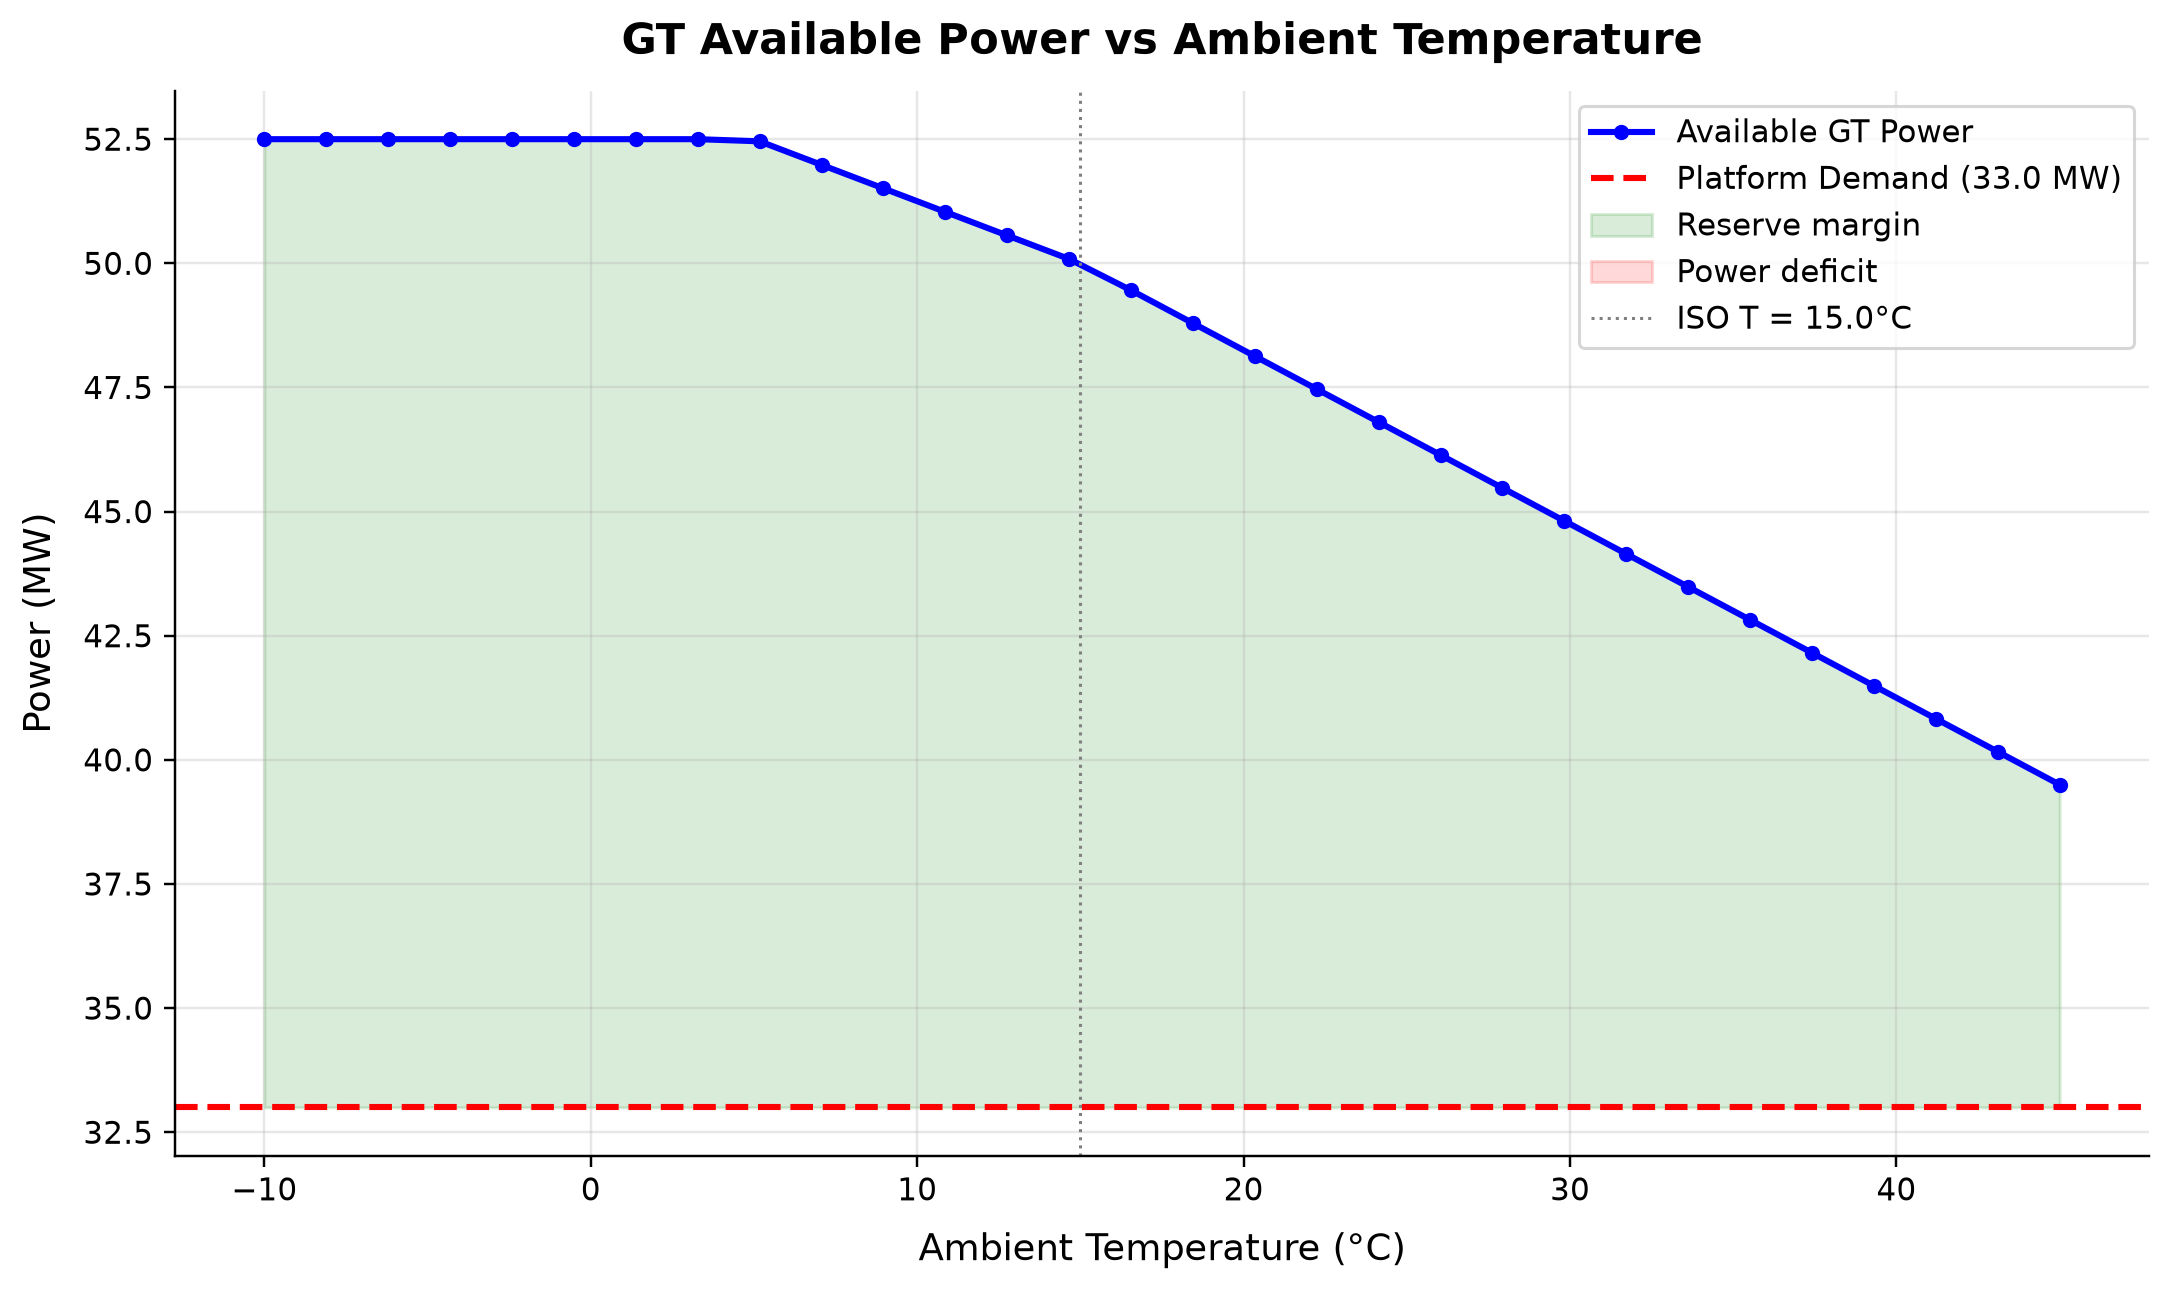

In [5]:
T_ISO = 15.0  # ISO standard temperature (°C)
K_DERATE = 0.007  # 0.7% per °C above ISO

ambient_temps = np.linspace(-10, 45, 30)
gt_available = []

for t_amb in ambient_temps:
    derate_factor = 1.0 - K_DERATE * max(t_amb - T_ISO, 0.0)
    # Below ISO, slight power increase (up to 5%)
    if t_amb < T_ISO:
        boost = min(0.005 * (T_ISO - t_amb), 0.05)
        derate_factor = 1.0 + boost
    gt_available.append(GT_RATED_POWER_MW * N_TURBINES * derate_factor)

gt_available = np.array(gt_available)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ambient_temps, gt_available, 'b-o', markersize=4, linewidth=2, label='Available GT Power')
ax.axhline(y=total_demand, color='red', linestyle='--', linewidth=2,
           label=f'Platform Demand ({total_demand:.1f} MW)')
ax.fill_between(ambient_temps, total_demand, gt_available,
                where=(gt_available >= total_demand), alpha=0.15, color='green', label='Reserve margin')
ax.fill_between(ambient_temps, total_demand, gt_available,
                where=(gt_available < total_demand), alpha=0.15, color='red', label='Power deficit')

ax.axvline(x=T_ISO, color='gray', linestyle=':', linewidth=1, label=f'ISO T = {T_ISO}°C')
ax.set_xlabel('Ambient Temperature (°C)', fontsize=12)
ax.set_ylabel('Power (MW)', fontsize=12)
ax.set_title('GT Available Power vs Ambient Temperature', fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch30_gt_ambient_temp.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ../figures/ch30_gt_ambient_temp.png")


**Executed-figure discussion.** Available GT Power: power spans 39.5–52.5 MW across the plotted cases.

Warmer inlet air generally reduces gas-turbine air mass flow and available power while changing compressor and turbine performance. The driver may reach its power limit on a hot day before the driven compressor reaches its own aerodynamic limit. Use the package’s ambient correction data and assess the hottest design case, degraded condition and required spinning reserve.


## 18.5 CO₂ Emissions from Gas Turbine Operation

CO₂ emissions are calculated from fuel gas composition and consumption rate.
For methane-rich fuel gas, the stoichiometric CO₂ yield is approximately
2.75 kg CO₂ per kg of natural gas burned.

CO₂ Emissions at Design Conditions:
  Fuel gas rate:    6789 kg/hr
  CO₂ rate:         18669 kg/hr
  Annual CO₂:       163537 tonnes/yr
  Specific CO₂:     565714 g/kWh
Figure saved: ../figures/ch30_co2_emissions.png


ch30_power_production.ipynb:cell11:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


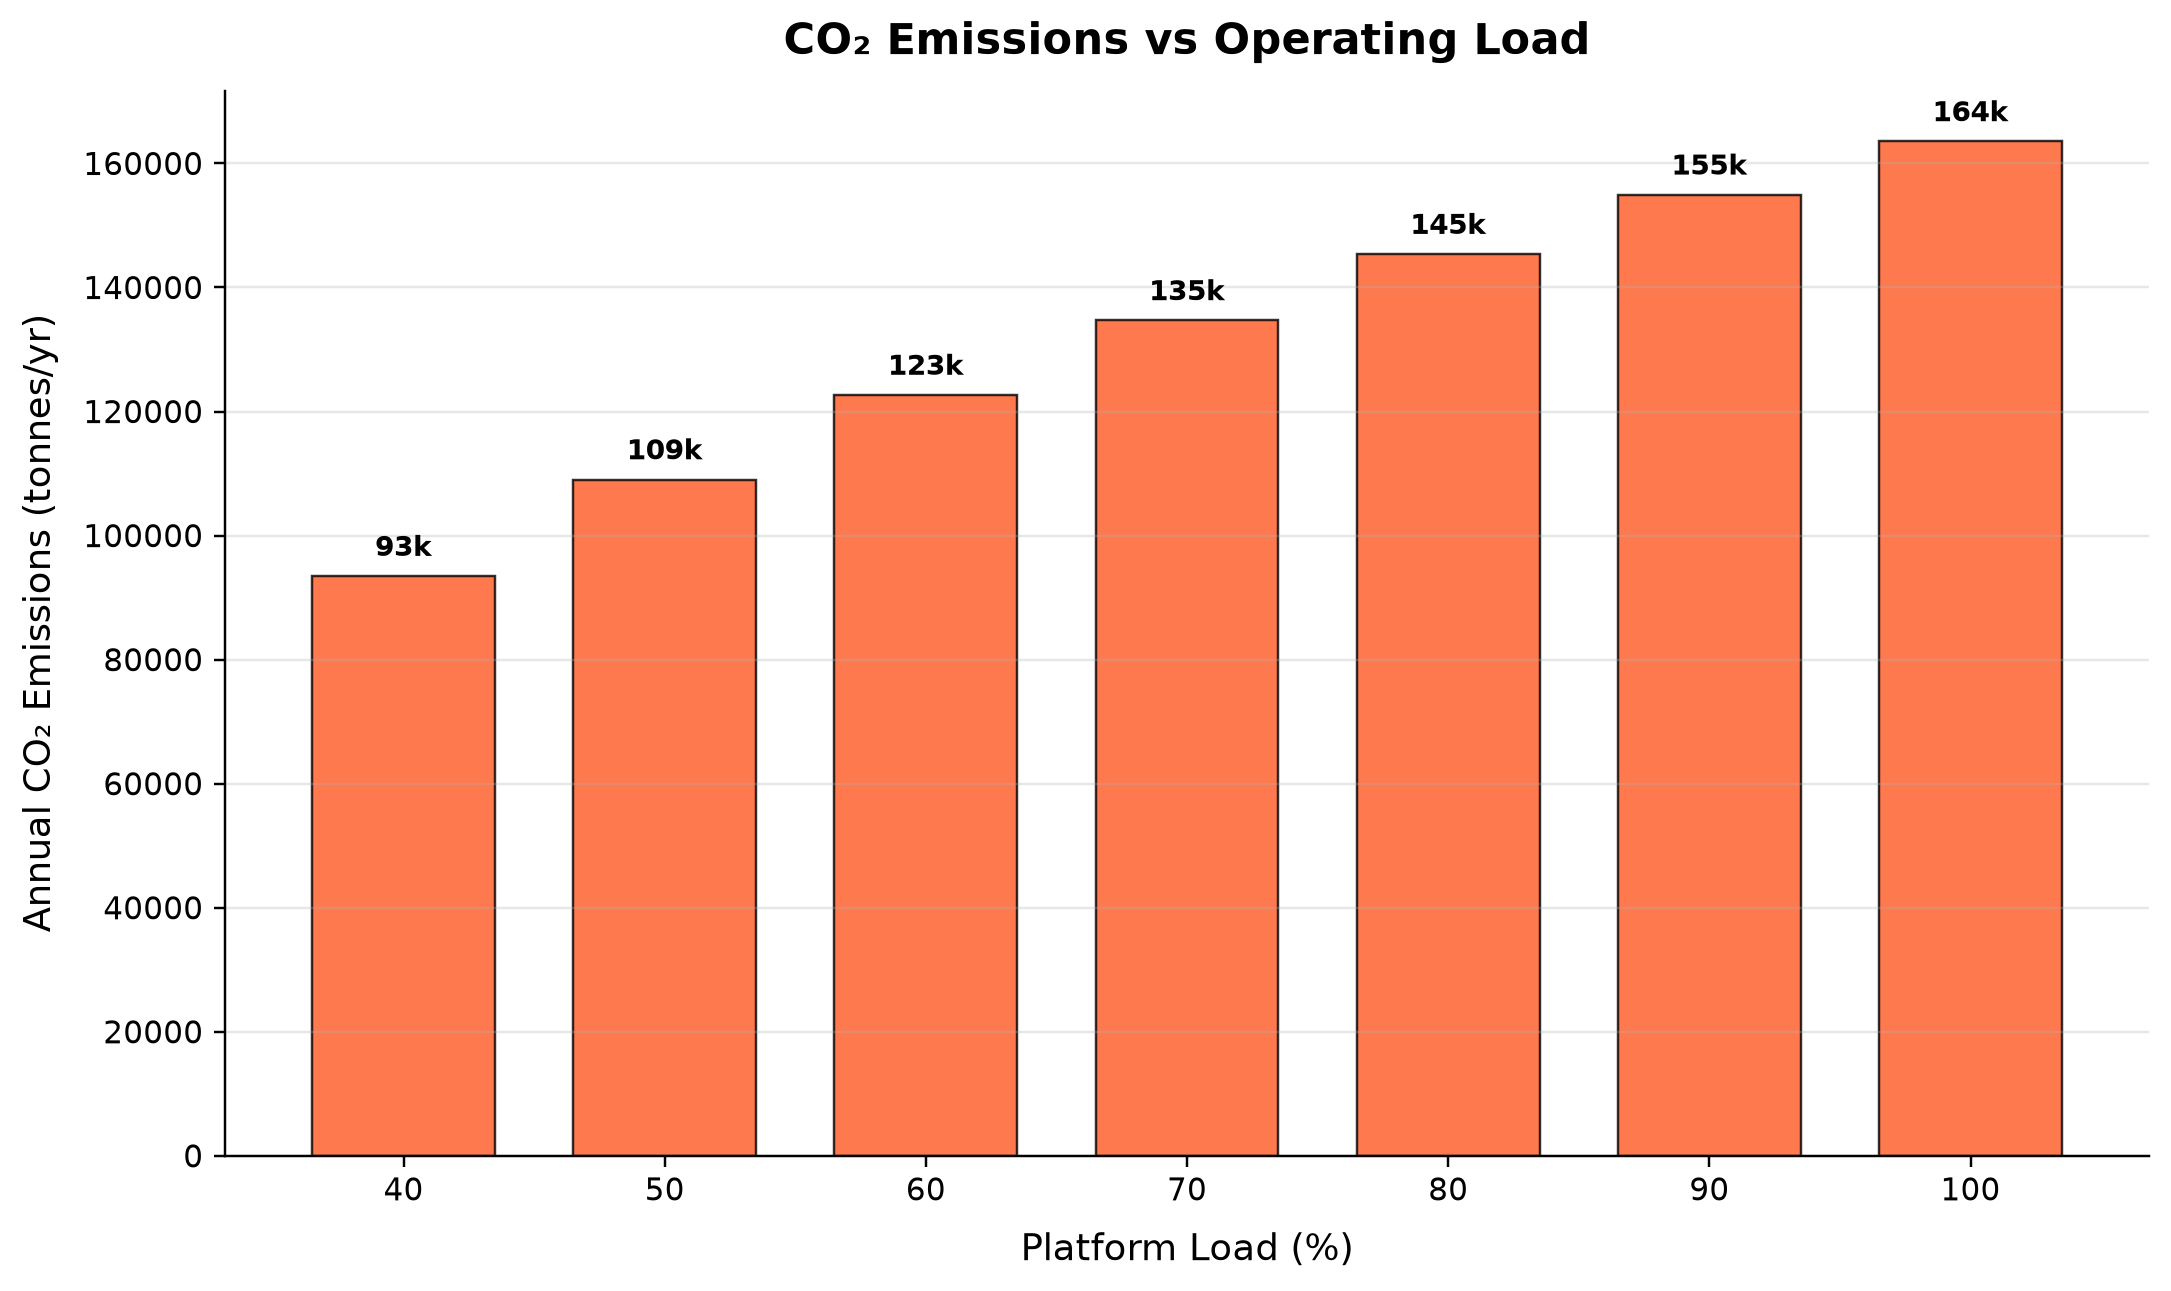

In [6]:
# CO2 emission factor (kg CO2 per kg fuel gas)
# CH4 + 2O2 -> CO2 + 2H2O  =>  16 kg CH4 -> 44 kg CO2  =>  2.75 kg CO2/kg CH4
CO2_FACTOR = 2.75  # kg CO2 per kg fuel gas (simplified for ~90% methane)

# Operating at current demand
fuel_at_demand = total_demand / GT_EFFICIENCY * 1000 / (LHV_MJ_per_kg / 3.6)  # kg/hr
co2_rate_kg_hr = fuel_at_demand * CO2_FACTOR
co2_rate_tonnes_yr = co2_rate_kg_hr * 8760 / 1000

print("CO₂ Emissions at Design Conditions:")
print(f"  Fuel gas rate:    {fuel_at_demand:.0f} kg/hr")
print(f"  CO₂ rate:         {co2_rate_kg_hr:.0f} kg/hr")
print(f"  Annual CO₂:       {co2_rate_tonnes_yr:.0f} tonnes/yr")
print(f"  Specific CO₂:     {co2_rate_kg_hr / (total_demand * 1000) * 1e6:.0f} g/kWh")

# Emissions at different load levels
load_levels_pct = np.array([40, 50, 60, 70, 80, 90, 100])
co2_emissions = []
for load_pct in load_levels_pct:
    load_frac = load_pct / 100.0
    power = total_demand * load_frac
    eta = GT_EFFICIENCY * (0.5 + 0.5 * load_frac)
    fuel = power / eta * 1000 / (LHV_MJ_per_kg / 3.6)
    co2 = fuel * CO2_FACTOR * 8760 / 1000  # tonnes/yr
    co2_emissions.append(co2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(load_levels_pct, co2_emissions, width=7, color='#FF5722', edgecolor='black',
       linewidth=0.8, alpha=0.8)
ax.set_xlabel('Platform Load (%)', fontsize=12)
ax.set_ylabel('Annual CO₂ Emissions (tonnes/yr)', fontsize=12)
ax.set_title('CO₂ Emissions vs Operating Load', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

for i, (load, co2) in enumerate(zip(load_levels_pct, co2_emissions)):
    ax.text(load, co2 + max(co2_emissions) * 0.02, f'{co2/1000:.0f}k',
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch30_co2_emissions.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ../figures/ch30_co2_emissions.png")


**Executed-figure discussion.** Annual CO₂ Emissions spans 9.345e+04–1.635e+05 tonnes/yr across the plotted cases.

Combustion CO2 follows fuel carbon consumption, while the operating-load dependence is shaped by prime-mover efficiency. A shaft-load reduction does not necessarily yield the same percentage reduction in fuel or emissions, especially at part load. Track absolute CO2 and emissions per unit product on a common fuel basis, and identify whether the inventory includes only combustion or also venting and fugitive methane.


## 18.6 Summary

Key findings on power production and energy management:

1. **Fuel efficiency drops at part load** — specific fuel consumption increases
   by ~30% at 50% load compared to full load, favoring fewer turbines at higher load

2. **Compression dominates power demand** — export and injection compressors
   consume ~60% of total platform power

3. **Ambient temperature derates GT power** — at 40°C, available power drops by
   ~17% from ISO-rated, which may eliminate the reserve margin in tropical locations

4. **CO₂ emissions scale non-linearly with load** — running at part load increases
   specific emissions, creating an incentive for load consolidation

For offshore platforms, the power system is often the key constraint that
limits production rate. Integrating power balance into production optimization
ensures that throughput targets are achievable within the available power envelope.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [7]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                   Figure  Panel                    Series                    Output / unit  Minimum  Maximum  Finite points  Missing points
ch30_fuel_consumption.png      1                   Curve 1            Fuel Gas Rate (kg/hr)  1714.29  5142.86             20               0
ch30_fuel_consumption.png      2                   Curve 1     Specific Fuel (kg/hr per MW)  205.714  342.857             20               0
ch30_fuel_consumption.png      3                Efficiency           Thermal Efficiency (%)       21       35             20               0
 ch30_gt_ambient_temp.png      1        Available GT Power                       Power (MW)     39.5     52.5             30               0
 ch30_gt_ambient_temp.png      1 Platform Demand (33.0 MW)                       Power (MW)       33       33              2               0
 ch30_gt_ambient_temp.png      1            ISO T = 15.0°C                       Power (MW)        0        1              2               0
   ch30_co2_e

## Physical verification and its limits
The assertions above test the calculated states and steady-state conservation laws. Rejected operating candidates remain excluded; they do not become synthetic outputs. The chapter-specific checks below state the applicable limits. Independent reference-fluid and analytic benchmarks are recorded separately in `verification/scientific_revision/benchmark_results.json`. Passing these checks does not establish field calibration or an installed equipment rating.


In [8]:
from chapter_specific_checks import validate_chapter
assert validate_chapter(_physics, globals())
assert _physics.finish()


Physics verification: 27 distinct checks, 27 evaluations; 0 rejected nonphysical candidates.


## Physical verification and scope

Fuel-energy and annual-emissions unit identities. Gas-turbine part-load curve, carbon factor and annual hours are assumptions; no emissions certification.

The final code cell checks the computed cases against explicit physical, analytical or constraint criteria. A passed conservation check establishes internal consistency; it does not establish field accuracy. Independent reference values, actual model results, units, acceptance tolerances and source provenance are retained in the [benchmark notebook](../../../verification/scientific_revision/36_benchmark_validation.ipynb), [benchmark results](../../../verification/scientific_revision/benchmark_results.json) and [chapter validation ledger](../../../verification/scientific_revision/notebook_physics_review.md).
